In [13]:
#Phase 1 – Import Libraries
# Import libraries for data manipulation
import pandas as pd
import numpy as np

# Import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Import libraries for machine learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Import libraries for model evaluation
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Ignore warning messages
import warnings
warnings.filterwarnings("ignore")

In [14]:
#Phase 2 – Load & Merge Dataset

from google.colab import files

# Upload the dataset
uploaded = files.upload()

Saving features.csv to features (2).csv
Saving stores.csv to stores (2).csv
Saving test.csv to test (2).csv
Saving train.csv to train (2).csv


In [15]:
# Step 1 - Load all datasets
train = pd.read_csv("train.csv")
features = pd.read_csv("features.csv")
stores = pd.read_csv("stores.csv")

# Step 2 - Merge train and features

df = pd.merge(
    train,
    features,
    on=["Store", "Date", "IsHoliday"],
    how="left"
)

# Step 3 - Merge with stores

df = pd.merge(
    df,
    stores,
    on="Store",
    how="left"
)

# Step 4 - Verify the merged dataset
# Display first 5 rows

df.head()

# Step 5 - Check the shape

print("Merged Dataset Shape:", df.shape)

Merged Dataset Shape: (421570, 16)


In [16]:
# Phase 3 – Data Understanding
# Step 1 - Display complete information about the dataset
df.info()

# Step 2 - Display all column names
print(df.columns)

# Step 3 - Count missing values in each column
df.isnull().sum()

# Step 4 - Count duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

# Step 5 - Display statistical summary
df.describe()

# Step 6 - Display dataset dimensions
print("Rows and Columns:", df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
 5   Temperature   421570 non-null  float64
 6   Fuel_Price    421570 non-null  float64
 7   MarkDown1     150681 non-null  float64
 8   MarkDown2     111248 non-null  float64
 9   MarkDown3     137091 non-null  float64
 10  MarkDown4     134967 non-null  float64
 11  MarkDown5     151432 non-null  float64
 12  CPI           421570 non-null  float64
 13  Unemployment  421570 non-null  float64
 14  Type          421570 non-null  object 
 15  Size          421570 non-null  int64  
dtypes: bool(1), float64(10), int64(3), object(2)
memory usage: 48.6+ MB
Index(['Store', 'Dept', 

In [17]:
# Phase 4 – Data Cleaning
# Step 1 - Check missing values in each column
print(df.isnull().sum())

# Step 2 - Fill missing values in MarkDown columns with 0

markdown_columns = [
    'MarkDown1',
    'MarkDown2',
    'MarkDown3',
    'MarkDown4',
    'MarkDown5'
]

df[markdown_columns] = df[markdown_columns].fillna(0)

# Step 3 - Convert Date column into datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Step 4 - Display updated data types
print(df.dtypes)

# Step 5 - Check missing values again
print(df.isnull().sum())

# Step 6 - Check duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

Store                0
Dept                 0
Date                 0
Weekly_Sales         0
IsHoliday            0
Temperature          0
Fuel_Price           0
MarkDown1       270889
MarkDown2       310322
MarkDown3       284479
MarkDown4       286603
MarkDown5       270138
CPI                  0
Unemployment         0
Type                 0
Size                 0
dtype: int64
Store                    int64
Dept                     int64
Date            datetime64[ns]
Weekly_Sales           float64
IsHoliday                 bool
Temperature            float64
Fuel_Price             float64
MarkDown1              float64
MarkDown2              float64
MarkDown3              float64
MarkDown4              float64
MarkDown5              float64
CPI                    float64
Unemployment           float64
Type                    object
Size                     int64
dtype: object
Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
Temperature     0
F

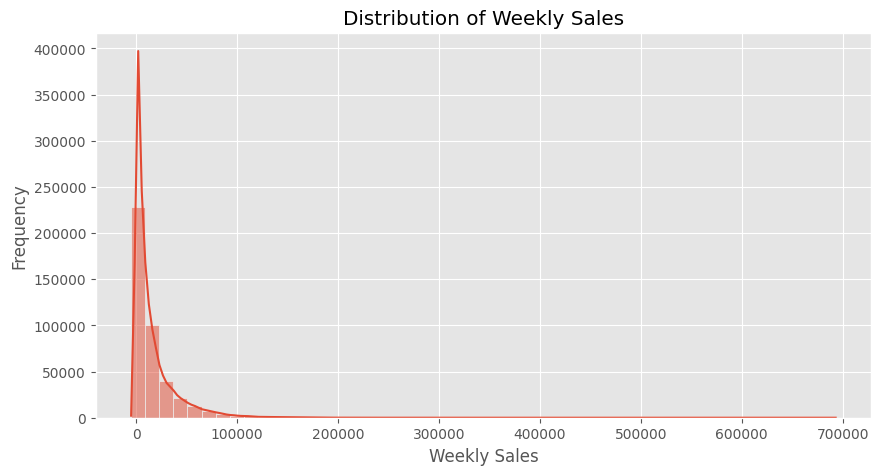

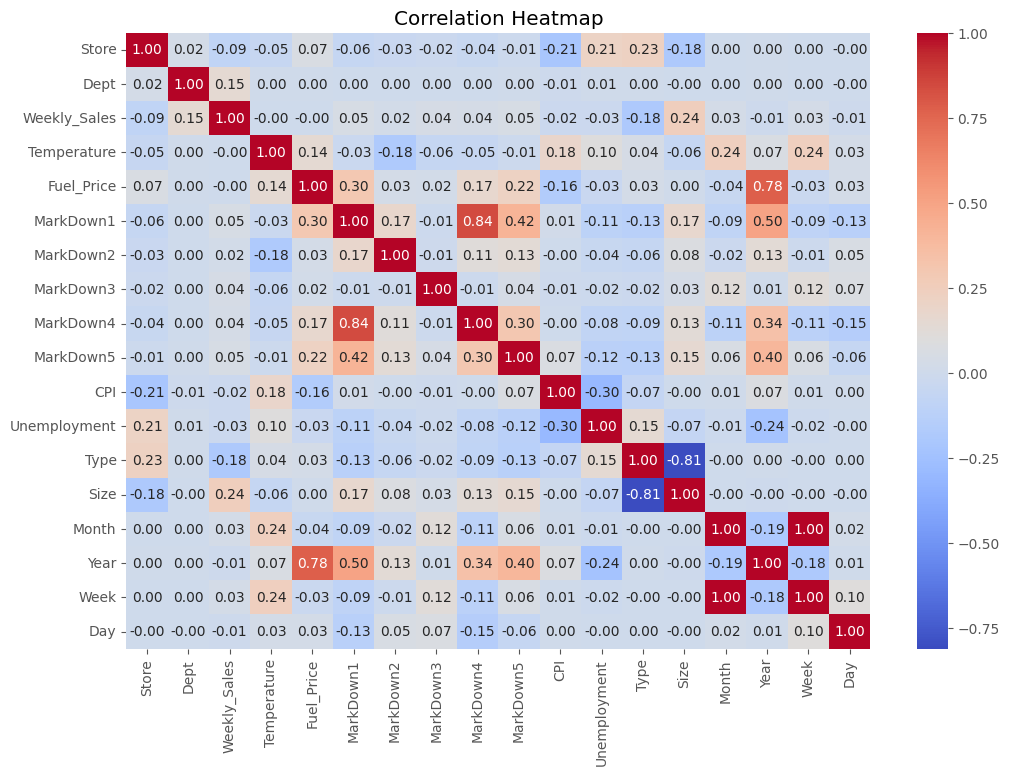

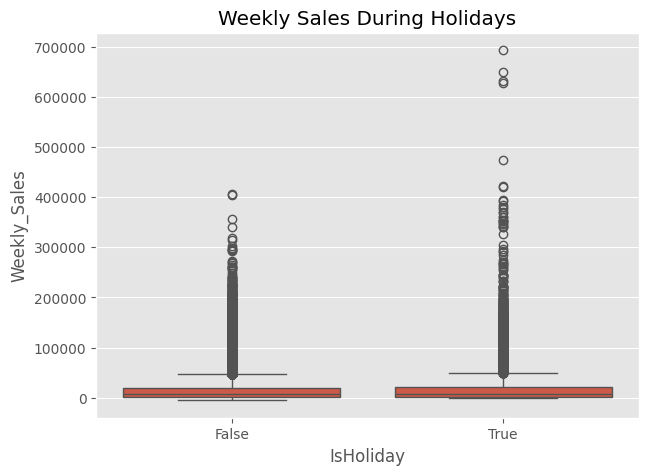

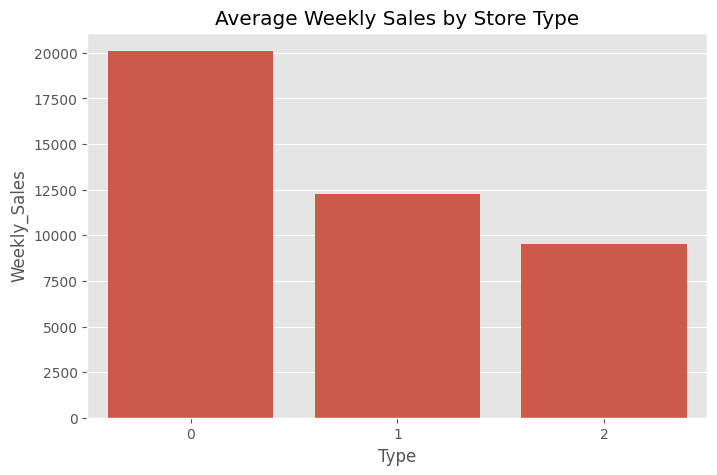

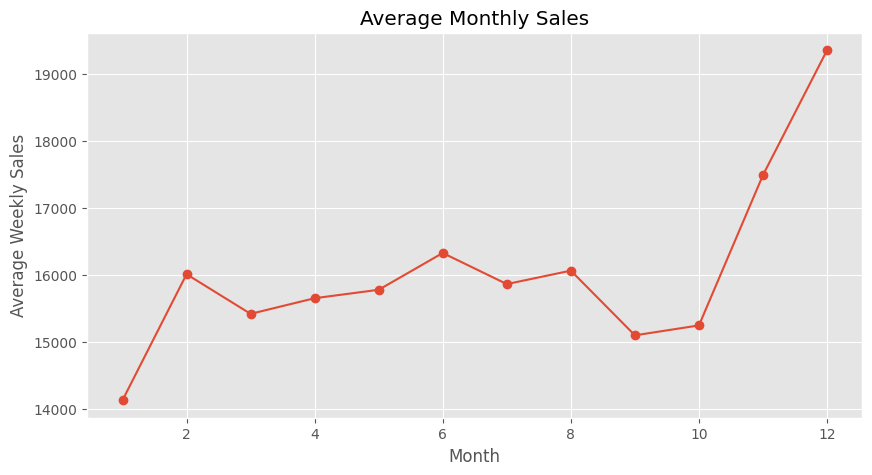

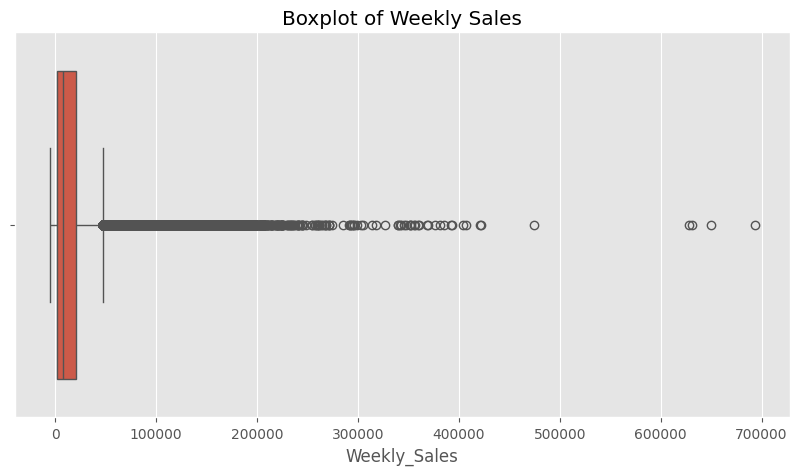

In [31]:
# Phase 5 – Exploratory Data Analysis (EDA)
# Step 1 – Import Visualization Libraries

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")


# Step 2 – Distribution of Weekly Sales

plt.figure(figsize=(10,5))

sns.histplot(df['Weekly_Sales'], bins=50, kde=True)

plt.title("Distribution of Weekly Sales")
plt.xlabel("Weekly Sales")
plt.ylabel("Frequency")

plt.show()

# Step 3 – Correlation Heatmap

plt.figure(figsize=(12,8))

numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()


# Step 4 – Sales During Holidays

plt.figure(figsize=(7,5))

sns.boxplot(
    x='IsHoliday',
    y='Weekly_Sales',
    data=df
)

plt.title("Weekly Sales During Holidays")

plt.show()


# Step 5 – Sales by Store Type

plt.figure(figsize=(8,5))

sns.barplot(
    x='Type',
    y='Weekly_Sales',
    data=df,
    estimator='mean',
    errorbar=None
)

plt.title("Average Weekly Sales by Store Type")

plt.show()

# Step 6 – Monthly Sales Trend
# Create Month column

df['Month'] = df['Date'].dt.month

monthly_sales = df.groupby('Month')['Weekly_Sales'].mean()

plt.figure(figsize=(10,5))

monthly_sales.plot(marker='o')

plt.title("Average Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Average Weekly Sales")

plt.grid(True)

plt.show()

# Step 7 – Detect Outliers

plt.figure(figsize=(10,5))

sns.boxplot(x=df['Weekly_Sales'])

plt.title("Boxplot of Weekly Sales")

plt.show()


In [20]:
# Phase 6 – Feature Engineering
# Step 1 – Extract Year

df['Year'] = df['Date'].dt.year

# Step 2 – Extract Month

df['Month'] = df['Date'].dt.month

# Step 3 – Extract Week Number
df['Week'] = df['Date'].dt.isocalendar().week.astype(int)

# Step 4 – Extract Day
df['Day'] = df['Date'].dt.day

# Step 5 – Encode Store Type
# Convert Store Type into numerical values
df['Type'] = df['Type'].map({
    'A': 0,
    'B': 1,
    'C': 2
})

# Step 6 – Verify the New Features
# Display the first 5 rows

df.head()

# Step 7 – Check Data Types

print(df.dtypes)



Store                    int64
Dept                     int64
Date            datetime64[ns]
Weekly_Sales           float64
IsHoliday                 bool
Temperature            float64
Fuel_Price             float64
MarkDown1              float64
MarkDown2              float64
MarkDown3              float64
MarkDown4              float64
MarkDown5              float64
CPI                    float64
Unemployment           float64
Type                     int64
Size                     int64
Month                    int32
Year                     int32
Week                     int64
Day                      int32
dtype: object


In [21]:
# Phase 7 – Feature Selection

# Step 1 – Create Features (X)
# Select input features
X = df.drop(columns=['Weekly_Sales', 'Date'])

# Step 2 – Create Target Variable (y)
# Select target variable
y = df['Weekly_Sales']

# Step 3 – Check Feature Shape
print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

# Step 4 – Display Feature Names
print("Selected Features:\n")
print(X.columns)

# Step 5 – Verify the Target Variable
print("Target Variable:")
print(y.head())



Features Shape: (421570, 18)
Target Shape: (421570,)
Selected Features:

Index(['Store', 'Dept', 'IsHoliday', 'Temperature', 'Fuel_Price', 'MarkDown1',
       'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI',
       'Unemployment', 'Type', 'Size', 'Month', 'Year', 'Week', 'Day'],
      dtype='object')
Target Variable:
0    24924.50
1    46039.49
2    41595.55
3    19403.54
4    21827.90
Name: Weekly_Sales, dtype: float64


In [22]:
# Phase 8 – Train-Test Split
# Step 1 – Split the Dataset
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Step 2 – Verify the Shapes

print("Training Features Shape :", X_train.shape)
print("Testing Features Shape  :", X_test.shape)

print()

print("Training Target Shape   :", y_train.shape)
print("Testing Target Shape    :", y_test.shape)




Training Features Shape : (337256, 18)
Testing Features Shape  : (84314, 18)

Training Target Shape   : (337256,)
Testing Target Shape    : (84314,)


In [23]:
# Phase 9 – Feature Scaling
# Step 1 – Import StandardScaler
from sklearn.preprocessing import StandardScaler

# Step 2 – Create the Scaler
# Create StandardScaler object
scaler = StandardScaler()

# Step 3 – Fit and Transform the Training Data
# Scale the training data
X_train_scaled = scaler.fit_transform(X_train)

# Step 4 – Transform the Testing Data
# Scale the testing data
X_test_scaled = scaler.transform(X_test)

# Step 5 – Verify the Shapes
print("Scaled Training Shape :", X_train_scaled.shape)
print("Scaled Testing Shape  :", X_test_scaled.shape)

Scaled Training Shape : (337256, 18)
Scaled Testing Shape  : (84314, 18)


In [24]:
# Phase 10 – Build the Linear Regression Model
# Step 1 – Create the Linear Regression Model
# Create the Linear Regression model
model = LinearRegression()

# Step 2 – Train the Model
# Train the model using the scaled training data
model.fit(X_train_scaled, y_train)

# Step 3 – Check the Model Coefficients
# Display model coefficients
print("Model Coefficients:")
print(model.coef_)

# Step 4 – Display the Intercept
# Display model intercept
print("Intercept:")
print(model.intercept_)


Model Coefficients:
[-1.18153985e+03  3.39693888e+03  1.04394035e+02  4.35317830e+02
  2.75160290e+02  1.63756638e+02  4.86287993e+01  5.56139600e+02
  8.00596538e+00  4.26995558e+02 -7.50117772e+02 -4.69145416e+02
  1.26997287e+03  6.19802877e+03 -2.28060855e+04 -9.63917254e+02
  2.32361886e+04 -2.21342193e+03]
Intercept:
15979.221911248405


In [25]:
# Phase 11 – Make Predictions
# Step 1 – Predict Weekly Sales
# Predict Weekly Sales using the testing data
y_pred = model.predict(X_test_scaled)

# Step 2 – Display the First 10 Predictions
# Display first 10 predicted values
print("Predicted Weekly Sales:\n")
print(y_pred[:10])

# Step 3 – Compare Actual vs Predicted
comparison = pd.DataFrame({
    'Actual Sales': y_test.values,
    'Predicted Sales': y_pred
})

comparison.head(10)



Predicted Weekly Sales:

[19850.62443754 20176.27277008  2076.32710708 10037.31711366
 25927.24671272 25888.70554753 12509.07964029 18637.59880575
 21101.59011235 20919.52593194]


,Actual Sales,Predicted Sales
0,50932.42,19850.624438
1,3196.12,20176.272770
2,10125.03,2076.327107
3,3311.26,10037.317114
4,6335.65,25927.246713
5,8971.23,25888.705548
6,1575.35,12509.079640
7,17308.45,18637.598806
8,5763.39,21101.590112
9,17034.57,20919.525932


In [26]:
# Phase 12 – Model Evaluation
# Step 1 – Calculate Evaluation Metrics

# Import evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Step 2 – Display the Results
print("Model Evaluation Results")
print("=" * 40)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

Model Evaluation Results
Mean Absolute Error (MAE): 14552.34
Mean Squared Error (MSE): 474753892.18
Root Mean Squared Error (RMSE): 21788.85
R² Score: 0.0896


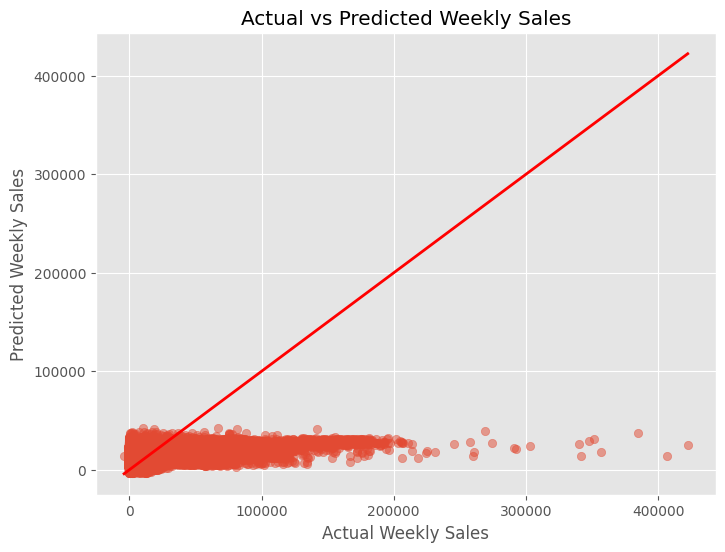

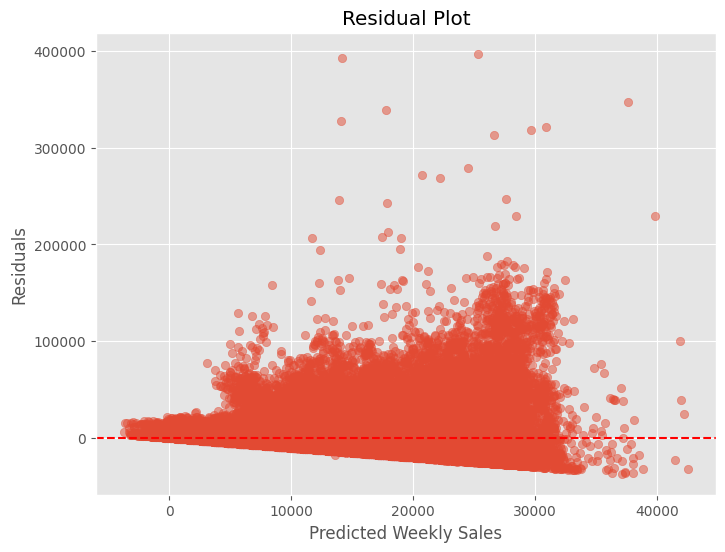

In [27]:
# Phase 13 – Visualize Actual vs Predicted Sales
# Step 1 – Actual vs Predicted Scatter Plot

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linewidth=2
)

plt.title("Actual vs Predicted Weekly Sales")
plt.xlabel("Actual Weekly Sales")
plt.ylabel("Predicted Weekly Sales")

plt.show()

# Step 2 – Residual Plot

residuals = y_test - y_pred

plt.figure(figsize=(8,6))

plt.scatter(y_pred, residuals, alpha=0.5)

plt.axhline(y=0, color='red', linestyle='--')

plt.title("Residual Plot")
plt.xlabel("Predicted Weekly Sales")
plt.ylabel("Residuals")

plt.show()



In [28]:
# Phase 14 – Predict Weekly Sales for New Data
# Step 1 – Create New Data
# New sample data
new_data = pd.DataFrame({
    'Store': [10],
    'Dept': [5],
    'IsHoliday': [0],
    'Temperature': [72.5],
    'Fuel_Price': [3.50],
    'MarkDown1': [5000],
    'MarkDown2': [2000],
    'MarkDown3': [1500],
    'MarkDown4': [3000],
    'MarkDown5': [2500],
    'CPI': [220.5],
    'Unemployment': [7.5],
    'Type': [0],      # A = 0
    'Size': [151315],
    'Month': [7],
    'Year': [2012],
    'Week': [27],
    'Day': [6]
})

# Step 2 – Scale the New Data
# Scale the new data
new_data_scaled = scaler.transform(new_data)

# Step 3 – Predict Weekly Sales
# Predict Weekly Sales
predicted_sales = model.predict(new_data_scaled)

# Step 4 – Display the Prediction
print("Predicted Weekly Sales:")
print(f"{predicted_sales[0]:.2f}")



Predicted Weekly Sales:
12126.33


In [29]:
# Phase 15 – Business Insights & Conclusion
# Step 1 – Business Insights

print("Business Insights")
print("=" * 50)

print("1. The Linear Regression model was successfully trained using historical Walmart sales data.")

print("2. Important factors such as Store, Department, Temperature, Fuel Price, CPI, Unemployment, MarkDown values, Store Type, and Store Size were used for prediction.")

print("3. The model predicted weekly sales for new unseen data successfully.")

print("4. The R² score is relatively low, indicating that Linear Regression could not fully capture the complex relationships in the Walmart sales data.")

print("5. The Actual vs Predicted plot and Residual plot show noticeable prediction errors, suggesting that the model can be improved.")

print("6. More advanced machine learning models such as Random Forest, XGBoost, or Gradient Boosting may provide better prediction accuracy.")

# Step 2 – Project Conclusion

print("\nProject Conclusion")
print("=" * 50)

print("This project successfully demonstrated the complete predictive analytics workflow.")

print("The project included:")
print("- Data Collection")
print("- Data Merging")
print("- Data Cleaning")
print("- Exploratory Data Analysis")
print("- Feature Engineering")
print("- Feature Selection")
print("- Train-Test Split")
print("- Feature Scaling")
print("- Linear Regression Model")
print("- Model Evaluation")
print("- Prediction on New Data")

print("\nOverall, the project provides a strong foundation for understanding predictive analytics using historical data.")



Business Insights
1. The Linear Regression model was successfully trained using historical Walmart sales data.
2. Important factors such as Store, Department, Temperature, Fuel Price, CPI, Unemployment, MarkDown values, Store Type, and Store Size were used for prediction.
3. The model predicted weekly sales for new unseen data successfully.
4. The R² score is relatively low, indicating that Linear Regression could not fully capture the complex relationships in the Walmart sales data.
5. The Actual vs Predicted plot and Residual plot show noticeable prediction errors, suggesting that the model can be improved.
6. More advanced machine learning models such as Random Forest, XGBoost, or Gradient Boosting may provide better prediction accuracy.

Project Conclusion
This project successfully demonstrated the complete predictive analytics workflow.
The project included:
- Data Collection
- Data Merging
- Data Cleaning
- Exploratory Data Analysis
- Feature Engineering
- Feature Selection
- Tra

In [34]:
# Download all saved graph files

from google.colab import files

graph_files = [
    "Distribution_Weekly_Sales.png",
    "Correlation_Heatmap.png",
    "Weekly_Sales_During_Holidays.png",
    "Average_Weekly_Sales_By_Store_Type.png",
    "Average_Monthly_Sales.png",
    "Weekly_Sales_Boxplot.png",
    "Actual_vs_Predicted_Weekly_Sales.png",
    "Residual_Plot.png"
]

for graph in graph_files:
    files.download(graph)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>